In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import BallStickZeppelinNoise
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx



sim_type = BallStickZeppelinNoise
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

In [67]:
from omegaconf import OmegaConf
res_folder = "/home/macke/mgloeckler90/dmri/results/dmri_bigger_longer_train"
config_path = res_folder + "/2025-03-08_18-16-00/0/.hydra/config.yaml"
cfg = OmegaConf.load(config_path)
print(cfg)

{'name': 'dmri_bigger_longer_train', 'seed': 0, 'use_wandb': True, 'wandb': {'project': 'dmri', 'entity': None}, 'simulator': {'sim_type': {'name': 'BallStickZeppelinNoise'}, 'acquisition_scheme': {'name': 'hardi', 'params': {'num_acquisitions': 200}}, 'prior_mask_alpha': 1.0, 'prior_mask_beta': 1.0}, 'model': {'embedding_net': {'name': 'DMRIEmbeddingConfig', 'params': {'num_layers': 2, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'bvals_embed_dim': 6, 'signals_embed_dim': 6, 'bvec_repeats': 2, 'log_transform_signals': True}}, 'inference_net': {'name': 'DMRIThetaInferenceConfig', 'params': {'num_layers': 6, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'context_dim': 64, 'dropout_rate': None}}, 'model_selection_net': {'name': 'DMRIModelSelectionAmortizedPriorConfig', 'params': {'num_layers': 4, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'context_dim': 64, 'mask_prior_dim': 1}}, 'init_seed': 0, 'name': 'DMRIInfer

In [68]:
from dmri.train.build_model import build_model
from dmri.train.build_simulator import build_simulator


sim_type, simulator = build_simulator(cfg)
model = build_model(cfg, sim_type)
model.eval()

graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)

In [69]:
# Learning rate scheduler and optimizer
import optax
optimizer_cfg = cfg.train.optimizer
optimizer_type = getattr(optax, optimizer_cfg.optimizer)
scheduler_type = getattr(optax, optimizer_cfg.scheduler)
use_ema = optimizer_cfg.get("ema", False)
use_adaptive_clip = optimizer_cfg.get("adaptive_gradient_clipping", False)
grad_transforms = []
if use_adaptive_clip:
    grad_clip = optax.adaptive_grad_clip(
        optimizer_cfg.get("gradient_clip_value", 10.0)
    )
    grad_transforms.append(grad_clip)
scheduler = scheduler_type(**optimizer_cfg.scheduler_params)
optimizer = optimizer_type(scheduler)
grad_transforms.append(optimizer)
if use_ema:
    grad_transforms.append(optax.ema(optimizer_cfg.get("ema_decay", 0.8)))

# Initialize optimizer
optimizer = optax.chain(*grad_transforms)

In [70]:
from dmri.train.checkpointing import CheckpointManager
checkpoint_dir = res_folder + "/checkpoints"
continue_training = True
checkpoint_manager = CheckpointManager(
        ckpt_dir=checkpoint_dir,
        max_to_keep=cfg.get("max_checkpoints", 3),
        keep_best=cfg.get("keep_best_checkpoint", True),
        recovery_threshold=cfg.get("recovery_threshold", float("inf")),
        continue_training=continue_training,
        use_async=cfg.get(
            "use_async_checkpointing", True
        ),  # Enable async checkpointing
    )

In [71]:
latest_step = checkpoint_manager.get_latest_step()
opt_state = optimizer.init(params)

In [72]:
checkpoint = checkpoint_manager.restore(
                step=latest_step, params=params, optimizer_state=opt_state
            )

In [73]:
params = checkpoint["params"]

In [74]:
model = nnx.merge(graphdef, params, static, state)
model.eval()

In [75]:
model.loss_fn

<bound method DMRIInferenceModel.loss_fn of DMRIInferenceModel(
  cfg=DMRIInferenceModelConfigMaskPriorAmortized(simulator=<class 'dmri.simulators.multi_compartment.BallStickZeppelinNoise'>, model_dim=128, embedding_cfg=DMRIEmbeddingConfig(num_layers=2, num_heads=4, widening_factor=4, attn_size=16, dropout_rate=None, bvals_embed_dim=6, signals_embed_dim=6, bvec_repeats=2, log_transform_signals=True), model_selection_cfg=DMRIModelSelectionAmortizedPriorConfig(num_layers=4, num_heads=4, widening_factor=4, attn_size=16, dropout_rate=None, context_dim=64, mask_prior_dim=1), theta_inference_cfg=DMRIThetaInferenceConfig(num_layers=6, num_heads=4, widening_factor=4, attn_size=16, context_dim=64, dropout_rate=None)),
  encoder=BvalBvecSignalEmbeddingNet(
    attn_size=16,
    bvec_repeats=2,
    embed_bvals=GaussianFourierEmbedding(
      B=Param(
        value=Array(shape=(4, 1), dtype=float32)
      ),
      input_dim=1,
      learnable=True,
      output_dim=6
    ),
    embed_signals=Gauss

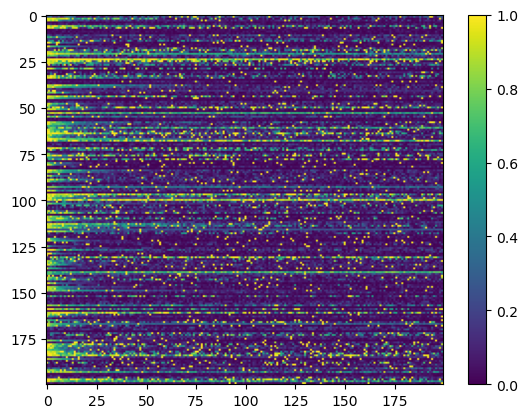

In [76]:
p_mask,masks, theta, x_o, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [77]:
model.eval()

In [78]:
model(masks, theta, x_o, acq.bvals, acq.bvecs, p_mask)[0][0]

(0, 1, 2, 3, 4)


Array([-16.867, -17.025, -17.16 , -13.603,  15.1  ], dtype=float32)

In [79]:
nnx.display(model)

In [80]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [81]:
p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [103]:
#idx = 2
idx = 12

In [104]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 128), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.5]))

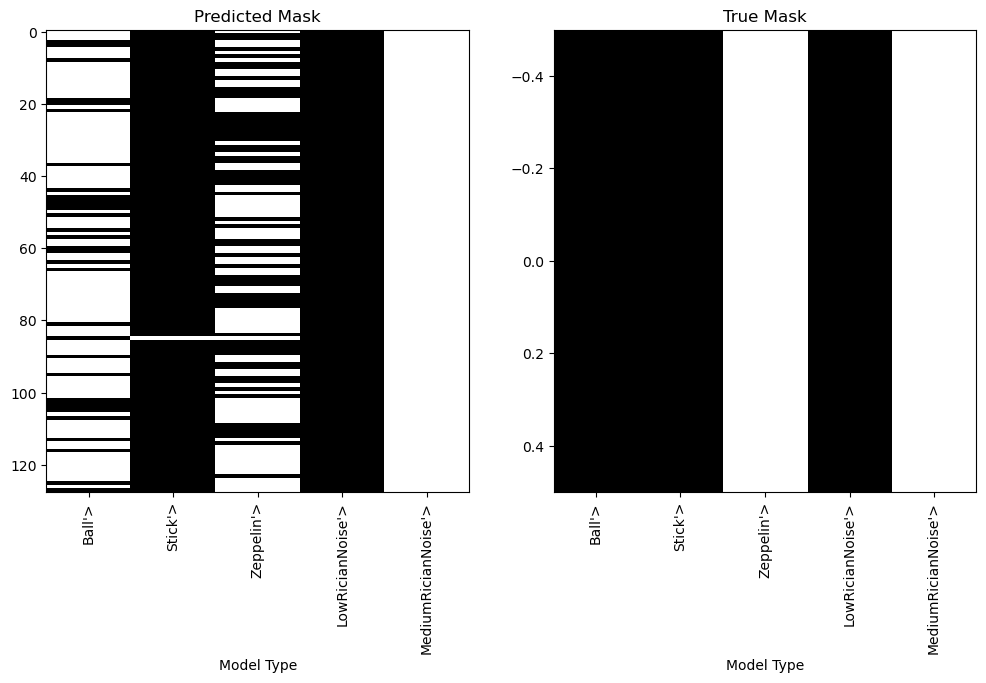

In [105]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

plt.show()

In [106]:
from functools import partial

In [107]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=80), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4)


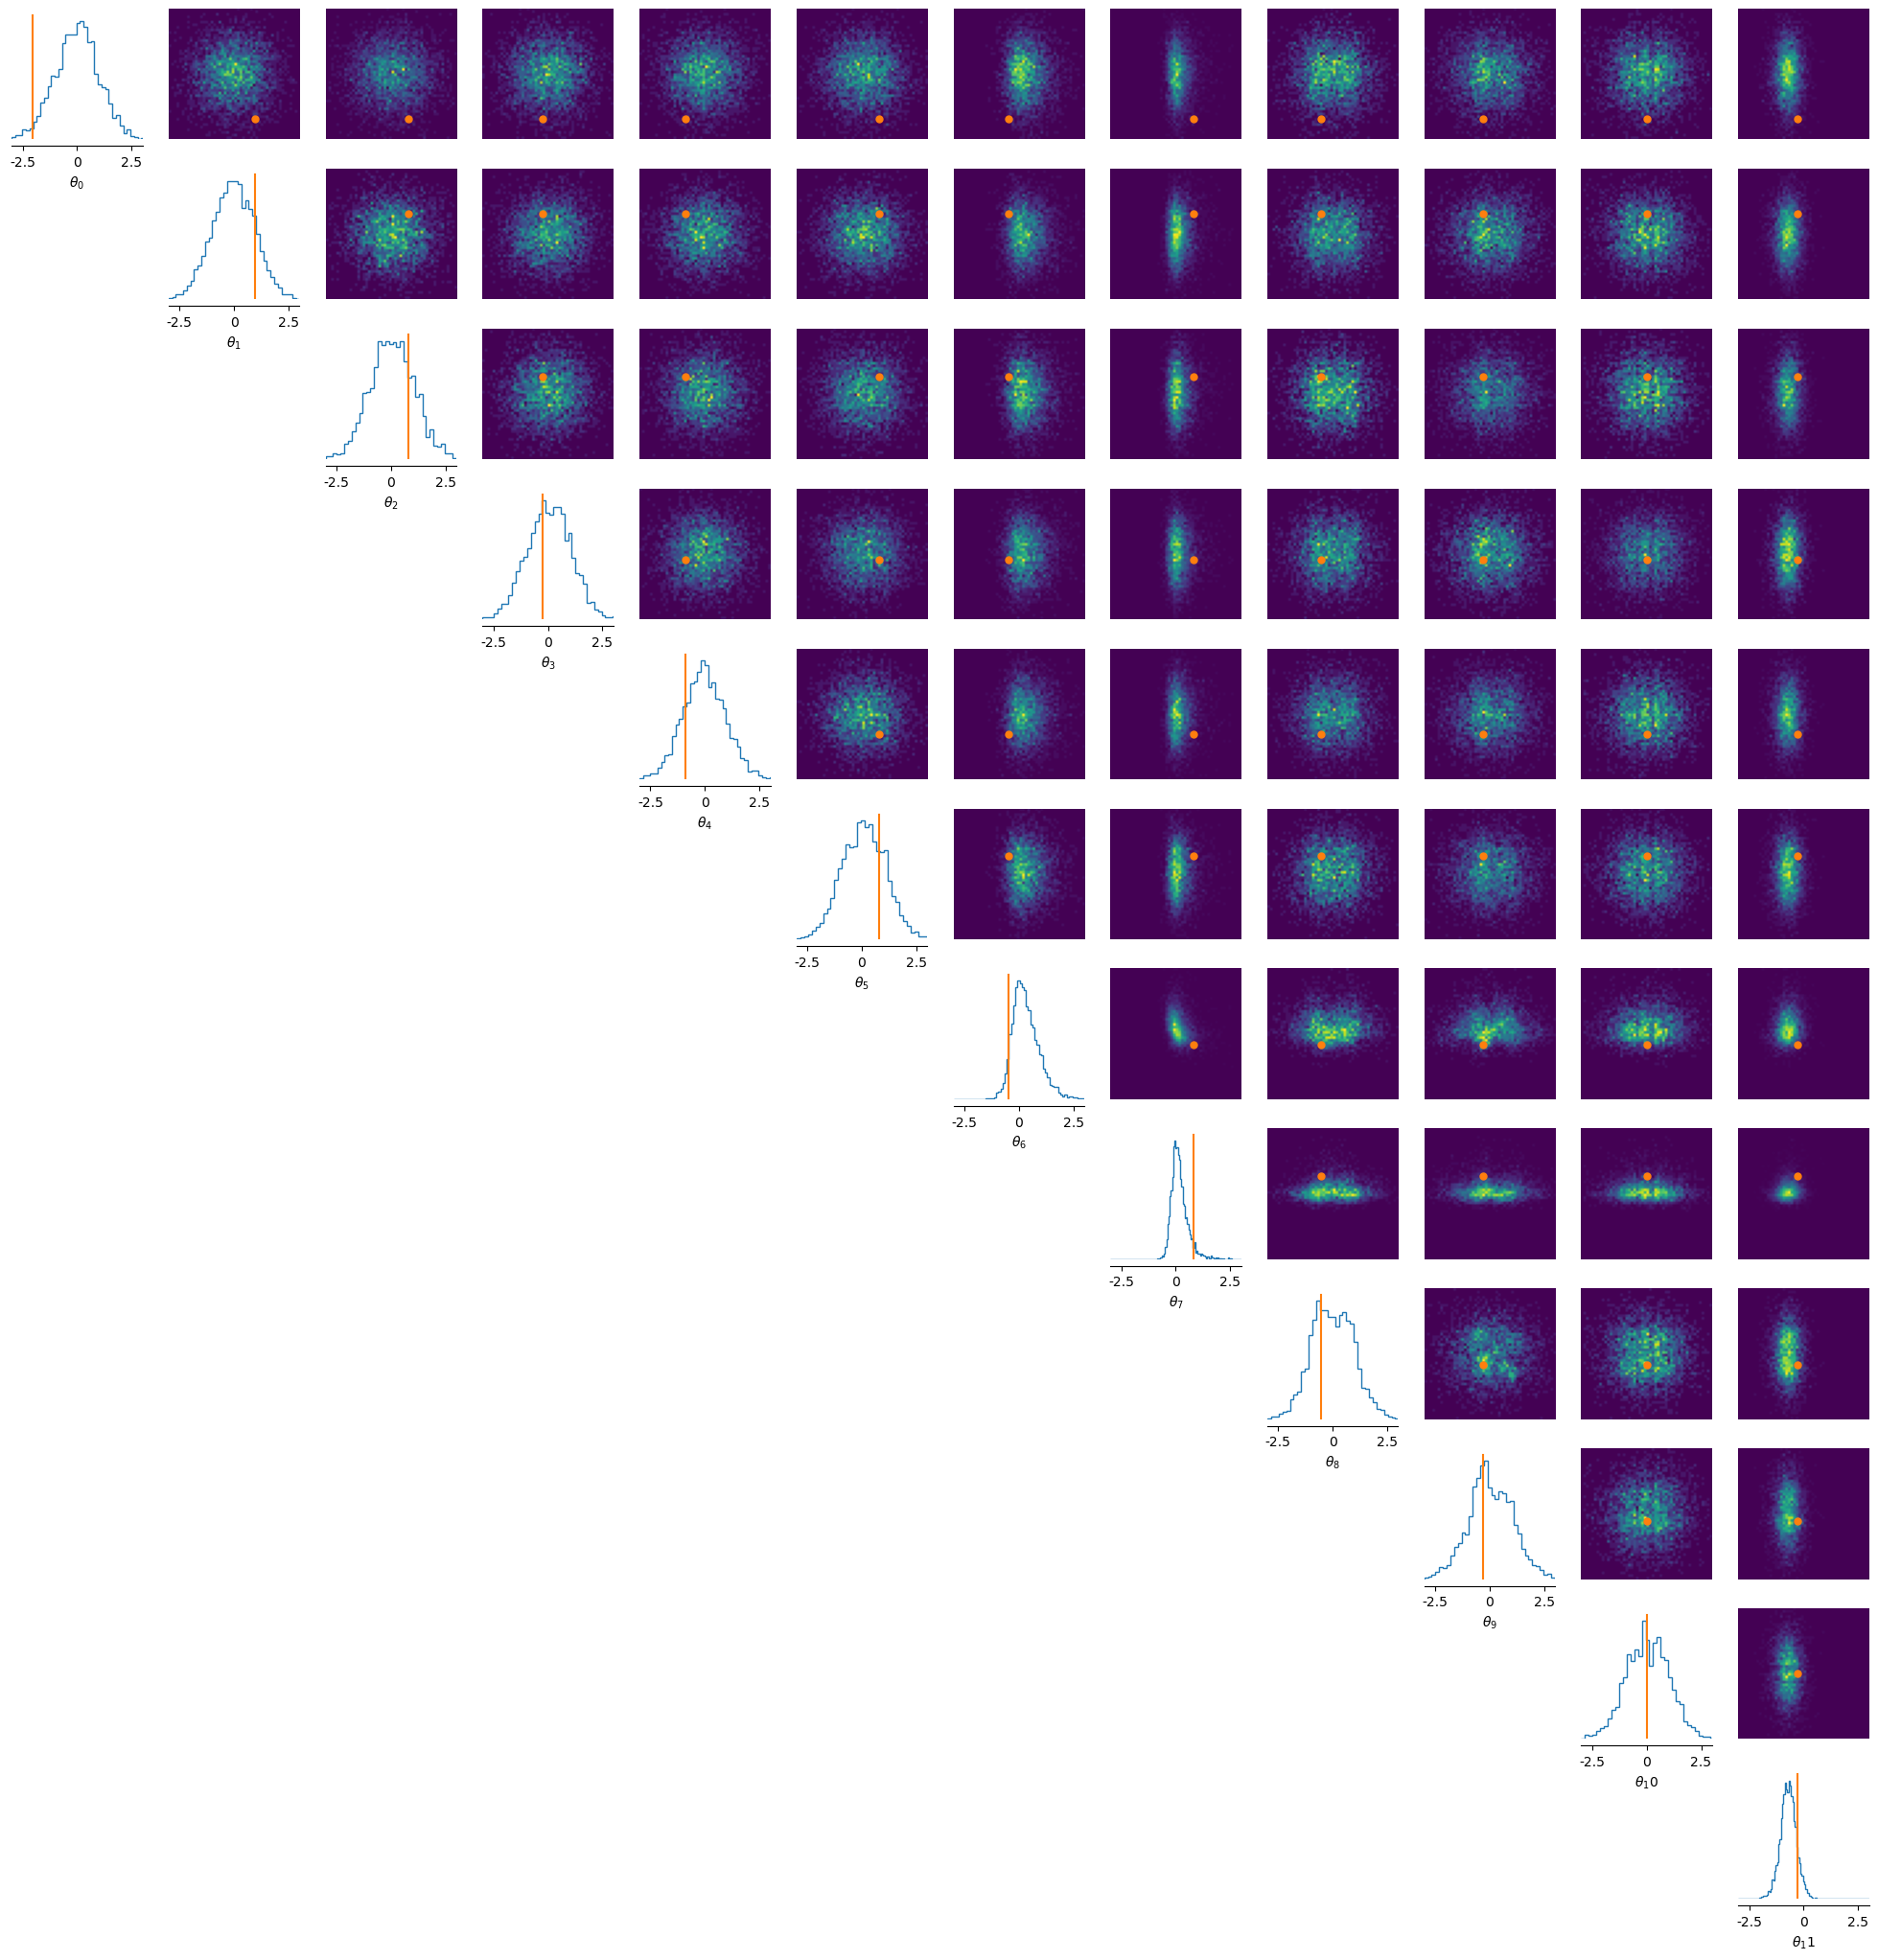

In [108]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [109]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

In [110]:
ll = loglikelihood(thetas[idx])

In [111]:
jnp.exp(-ll)

Array(0., dtype=float32)

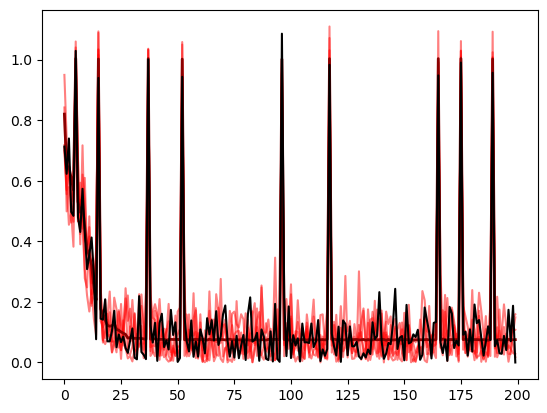

In [112]:
_ = plt.plot(posterior_preds[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_os[idx], label="data", color="black")

In [117]:
def log_posterior(theta):
    return loglikelihood(theta) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def log_q(theta):
    return model.log_prob_theta(theta, acq.bvals[idx], acq.bvecs[idx], x_os[idx], masks[idx], num_steps=64, max_noise=10)

@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(log_posterior)(thetas)
    logq = jax.vmap(log_q)(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [118]:
effectve_sample_size(thetas_post)

(0, 1, 2, 3, 4)


Array(29.914, dtype=float32)

In [119]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")

data, affine = load_nifti(hardi_fname)

bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)


In [120]:
from dipy.segment.mask import median_otsu

datamask, mask = median_otsu(
    data, vol_idx=range(10, 50), median_radius=3, numpass=1, autocrop=True, dilate=2
)
b0_mask = bvals == 0

In [121]:
# Data sub
S0 = np.mean(datamask[..., b0_mask], -1)
data_norm = datamask / S0[..., None]
x_o = data_norm[13:43, 44:74, 28:29].squeeze()
S_o = S0[13:43, 44:74, 28:29].squeeze()


/tmp/ipykernel_2347291/3122232576.py:3: RuntimeWarning: divide by zero encountered in divide
  data_norm = datamask / S0[..., None]
/tmp/ipykernel_2347291/3122232576.py:3: RuntimeWarning: invalid value encountered in divide
  data_norm = datamask / S0[..., None]


Text(0.5, 1.0, 'HCP coronal slice B0 with ROI')

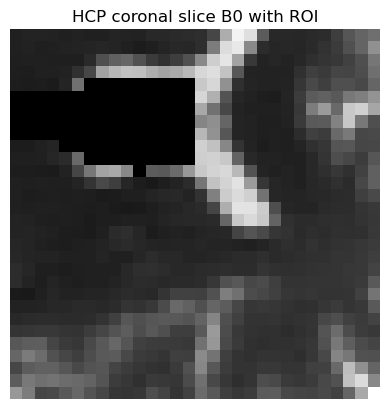

In [122]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
ax.set_title('HCP coronal slice B0 with ROI')

In [123]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [141]:
sample_mask_per_x= jax.jit(jax.vmap(lambda k, x: model.sample_mask(k, acq.bvals, acq.bvecs, x, mask_prior=jnp.array([0.05])), in_axes=(0,0)))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

mask = sample_mask_per_x(jax.random.split(jax.random.key(0), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
for i in range(1,100):
    mask += sample_mask_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat).astype(jnp.float32)
p_models = mask / 100

In [142]:
p_models

Array([[0.07, 0.39, 0.98, 1.  , 0.  ],
       [0.08, 0.12, 1.  , 1.  , 0.  ],
       [0.03, 0.99, 1.  , 1.  , 0.  ],
       ...,
       [0.05, 1.  , 1.  , 1.  , 0.  ],
       [0.19, 0.34, 0.87, 1.  , 0.  ],
       [0.17, 0.92, 1.  , 1.  , 0.  ]], dtype=float32)

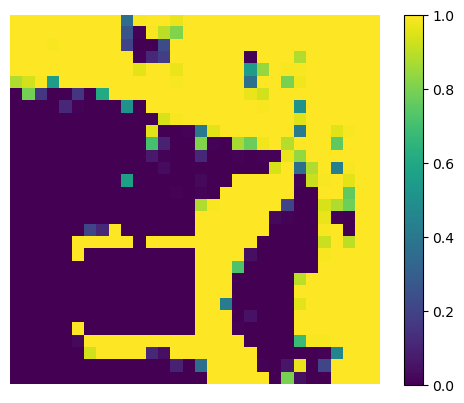

In [143]:
fig, ax = plt.subplots(1)
l = ax.imshow(p_models[:,3].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

In [144]:
model_mask = jnp.array([True, True, False, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
for i in range(10):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))


(0, 1, 2, 3, 4)


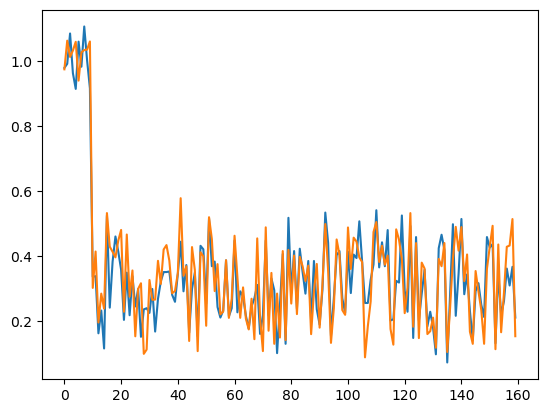

In [145]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])
i = 13
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

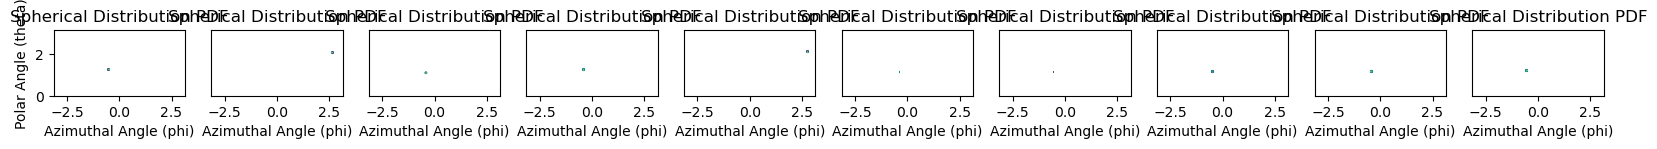

In [146]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for j in range(10):
    fod = sim_type.from_theta(thetas[j][i], model_mask=model_mask).to_fod()
    fod.viz(plot_type="polar",n_samples=5_00, ax=axes[j])
    if j > 0:
        axes[j].set_ylabel("")
        axes[j].set_yticks([])

In [147]:
def to_params_dict(theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fractions = simulator.model_fractions
    components = simulator.model_compartments
    noise = simulator.noise_compartments

    com_params = [c.params for c in components]
    noise_params = [n.params for n in noise]
    return {"fractions": fractions, "components": com_params, "noise": noise_params}

In [148]:
from dmri.utils.dmriutils import unitsphere_to_cartesian


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)


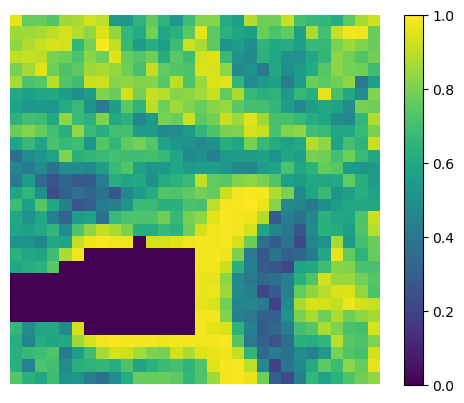

In [154]:
fig, ax = plt.subplots(1)
l = ax.imshow(frac[:,0].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

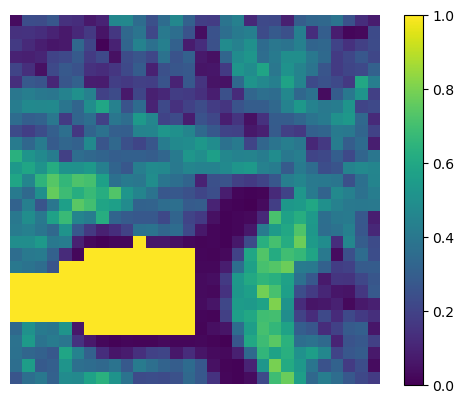

In [155]:
fig, ax = plt.subplots(1)
l = ax.imshow(frac[:,1].reshape(30,30), vmin=0,vmax=1.)
ax.set_axis_off()
plt.colorbar(l)

In [156]:


all_params = jax.vmap(to_params_dict)(thetas[0])
frac = all_params["fractions"]
lam_iso = all_params["components"][0]["lam"]
lam_par = all_params["components"][1]["lam_par"]
mu = all_params["components"][1]["mu"]
direction = jax.vmap(unitsphere_to_cartesian)(mu)

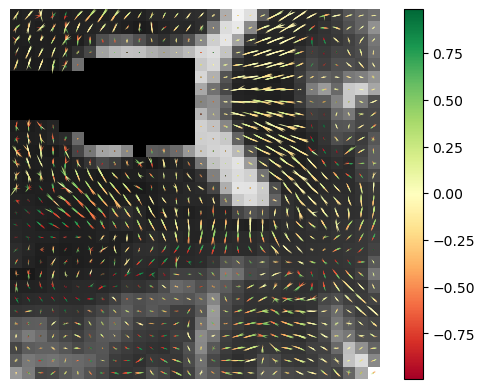

In [157]:
fig, ax = plt.subplots(1)
ax.imshow(S_o.reshape(30, 30), cmap='gray', origin='lower')


for i in range(10):
    # For example, use the first sample in thetas
    all_params = jax.vmap(to_params_dict)(thetas[i])
    frac    = all_params["fractions"]
    lam_par = all_params["components"][1]["lam_par"]
    mu      = all_params["components"][1]["mu"]

    # Convert unit sphere directions to 3D cartesian coordinates.
    direction = jax.vmap(unitsphere_to_cartesian)(mu)
    # Compute 2D projection using the first two components.
    direction_2d = direction[:, :2] * frac[:, 1][:, None] * (lam_par[:, None] > 0)

    # Use the third component (z) as the color code.
    colors = direction[:, 2]

    # Create a grid for quiver
    X, Y = np.meshgrid(np.arange(30), np.arange(30))
    q = ax.quiver(X, Y, direction_2d[:, 0].reshape(30, 30),
                  direction_2d[:, 1].reshape(30, 30),
                  colors.reshape(30, 30), cmap="RdYlGn", scale=25, headwidth=0, headlength=0)
plt.colorbar(q)
ax.set_axis_off()
plt.show()

In [158]:
# Ball and Zeppelins

model_mask = jnp.array([True, True, True, False, True], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=128, max_noise=80), in_axes=(0,0)))

thetas = []
for i in range(10):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred


(0, 1, 2, 3, 4)


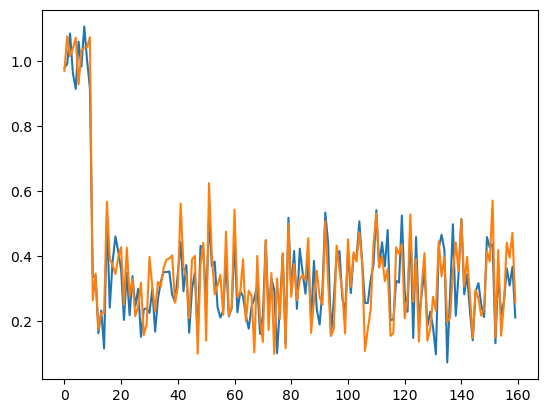

In [159]:
x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[3])

i = 13
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")

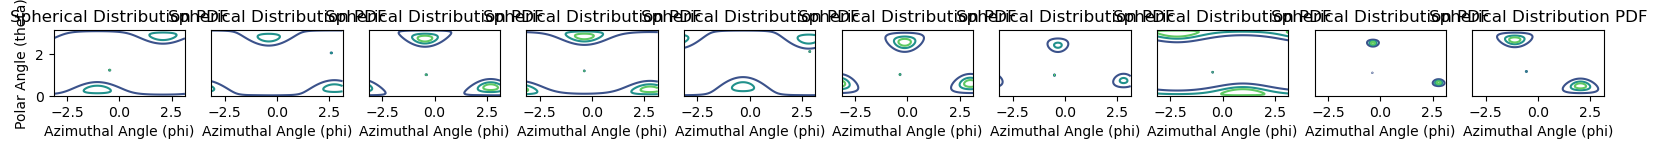

In [160]:
fig, axes = plt.subplots(1, 10, figsize=(20, 2))

for j in range(10):
    fod = sim_type.from_theta(thetas[j][i], model_mask=model_mask).to_fod()
    fod.viz(plot_type="polar",n_samples=5_00, ax=axes[j])
    if j > 0:
        axes[j].set_ylabel("")
        axes[j].set_yticks([])

In [161]:
def to_fod_sample(theta, rng):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    fod = simulator.to_fod()
    return fod.fractions, fod.sample(rng, shape=(20,))

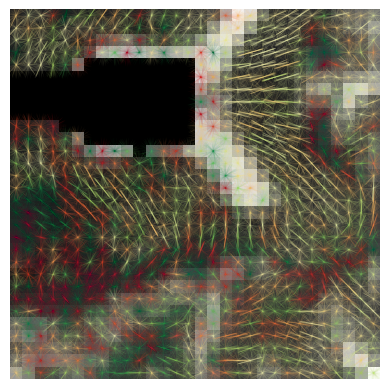

In [162]:
fig, ax = plt.subplots(1)
ax.imshow(S_o.reshape(30, 30), cmap='gray', origin='lower')

for i in range(6):
    theta = thetas[i]
    fractions, directions = jax.vmap(to_fod_sample)(theta, jax.random.split(jax.random.key(i), theta.shape[0]))
    for i in range(20):
        direction_2d = directions[:, i,:2]

        # Use the third component (z) as the color code.
        colors = direction[:, 2]

        # Create a grid for quiver
        X, Y = np.meshgrid(np.arange(30), np.arange(30))
        q = ax.quiver(X, Y, direction_2d[:, 0].reshape(30, 30),
                    direction_2d[:, 1].reshape(30, 30),
                    colors.reshape(30, 30), cmap="RdYlGn", scale=25, headwidth=0, headlength=0, alpha=0.05)
ax.set_axis_off()
plt.show()

In [1]:
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames, small_sphere
from dipy.direction import ProbabilisticDirectionGetter, peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.stateful_tractogram import Space, StatefulTractogram
from dipy.io.streamline import save_trk
from dipy.reconst.csdeconv import ConstrainedSphericalDeconvModel, auto_response_ssst
from dipy.reconst.shm import CsaOdfModel
from dipy.tracking import utils
from dipy.tracking.local_tracking import LocalTracking
from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
from dipy.tracking.streamline import Streamlines
from dipy.viz import actor, colormap, has_fury, window

# Enables/disables interactive visualization
interactive = False

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

In [2]:
csa_model = CsaOdfModel(gtab, sh_order_max=6)
gfa = csa_model.fit(data, mask=white_matter).gfa
stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

In [3]:


fod = csd_fit.odf(small_sphere)
pmf = fod.clip(min=0)
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf, max_angle=30.0, sphere=small_sphere
)
streamline_generator = LocalTracking(
    prob_dg, stopping_criterion, seeds, affine, step_size=0.5
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf.png", size=(800, 800)
)

In [4]:
img = plt.imread("tractogram_probabilistic_dg_pmf.png")
plt.imshow(img)

NameError: name 'plt' is not defined

In [19]:
from dipy.data import default_sphere, get_fnames, small_sphere
x_o_full = np.nan_to_num(data)

In [20]:
x_o_select = x_o_full[white_matter]
x_o_select_b0 = x_o_select[..., bvals == 0]
x_o_select = x_o_select / x_o_select_b0.mean(-1)[..., None]

In [21]:
x_o_select_flat = x_o_select.reshape(-1, x_o_full.shape[-1])

In [22]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [78]:
model_mask = jnp.array([True, True, True, False, True], dtype=jnp.bool)
def sample_pmf(key, x):
    sample_fn = lambda k: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=16, max_noise=20)
    pmf = 0

    def scan_fn(carry, key):
        thetas = jax.vmap(sample_fn)(jax.random.split(key,5))

        def to_pmf(theta):
            simulator = sim_type.from_theta(theta, model_mask=model_mask)
            return simulator.to_fod().to_pmf(small_sphere)

        pmf = 0
        for theta in thetas:
            pmf += to_pmf(theta)

        pmf_contrib = pmf / 5
        return carry + pmf_contrib, None

    # Use the first theta to determine the shape of the accumulator:
    init_sim = sim_type.from_theta(jnp.zeros(sim_type.theta_dim), model_mask=model_mask)
    init_pmf = init_sim.to_fod().to_pmf(small_sphere) * 0  # zeros of the same shape

    carry, _ = jax.lax.scan(scan_fn, init_pmf, jax.random.split(key, 10))
    pmf = carry

    return pmf / 10

batch_sample_pmf = jax.jit(jax.vmap(sample_pmf, in_axes=(0,0)))

In [79]:
pms = []
# Laptop has just 4GB of VRAM, so we need to split the computation
num_iters = x_o_select_flat.shape[0] // 3000 + 1

for i in range(num_iters):
    with jax.default_device(jax.devices("gpu")[0]):
        x_o_batch = x_o_select_flat[i*3000:(i+1)*3000]
        keys = jax.random.split(jax.random.key(i), x_o_batch.shape[0])
        pmf1 = batch_sample_pmf(keys,x_o_batch)
    pms.append(jax.device_put(pmf1, jax.devices("cpu")[0]))
    print(i)

(0, 1, 2, 3, 4)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
(0, 1, 2, 3, 4)
19


In [80]:
pmf = jnp.concatenate(pms, axis=0)
pmf = pmf[:x_o_select_flat.shape[0]]
#pmf = pmf.reshape(x_o_select.shape[0], x_o_select.shape[1], x_o_select.shape[2], pmf.shape[-1])

In [81]:
x_o_select.shape

(58788, 160)

In [82]:
pmf = np.array(pmf)
pmf = np.nan_to_num(pmf, nan=1e-6)
pmf = np.clip(pmf, 0, 1)
pmf = pmf / pmf.sum(-1, keepdims=True)

In [83]:
pmf_full = np.zeros(data.shape[:-1] + (181,))
pmf_full[white_matter] = pmf

In [84]:
# np.save("pmf_full.npy", pmf_full)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
pmf_full = np.load("pmf_full.npy")

(0.0, 0.1)

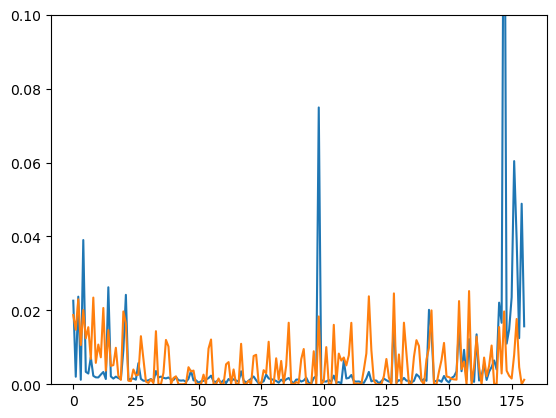

In [11]:
idx = 14
_ = plt.plot(pmf_full[white_matter][idx])
_ = plt.plot(pmf_dipy[white_matter][idx]/pmf_dipy[white_matter][idx].sum())
plt.ylim(0, 0.1)


In [12]:
data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

seed_mask = labels == 2
white_matter = (labels == 1) | (labels == 2)
seeds = utils.seeds_from_mask(seed_mask, affine, density=1)

response, ratio = auto_response_ssst(gtab, data, roi_radii=10, fa_thr=0.7)
csd_model = ConstrainedSphericalDeconvModel(gtab, response, sh_order_max=6)
csd_fit = csd_model.fit(data, mask=white_matter)

fod = csd_fit.odf(small_sphere)
pmf_dipy = fod.clip(min=0)

In [13]:
from dipy.tracking.stopping_criterion import CmcStoppingCriterion
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")
f_pve_csf, f_pve_gm, f_pve_wm = get_fnames(name="stanford_pve_maps")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)


pve_csf_data = load_nifti_data(f_pve_csf)
pve_gm_data = load_nifti_data(f_pve_gm)
pve_wm_data, _, voxel_size = load_nifti(f_pve_wm, return_voxsize=True)

voxel_size = np.average(voxel_size[1:4])
step_size = 0.2

cmc_criterion = CmcStoppingCriterion.from_pve(
    pve_wm_data,
    pve_gm_data,
    pve_csf_data,
    step_size=step_size,
    average_voxel_size=voxel_size,
)

In [14]:
# data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
# labels = load_nifti_data(label_fname)
# bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
# gtab = gradient_table(bvals, bvecs=bvecs)

# csa_model = CsaOdfModel(gtab, sh_order_max=6)
# gfa = csa_model.fit(data, mask=white_matter).gfa
# stopping_criterion = ThresholdStoppingCriterion(gfa, 0.25)

In [18]:
prob_dg = ProbabilisticDirectionGetter.from_pmf(
    pmf_full, max_angle=35.0, sphere=small_sphere
)
# streamline_generator = LocalTracking(
#     prob_dg, stopping_criterion, seeds, affine, step_size=0.01
# )
from dipy.tracking.local_tracking import LocalTracking, ParticleFilteringTracking

streamline_generator = ParticleFilteringTracking(
    prob_dg,
    cmc_criterion,
    seeds,
    affine,
    max_cross=3,
    step_size=0.5,
    maxlen=10_000,
    pft_back_tracking_dist=3,
    pft_front_tracking_dist=2,
    particle_count=500,
    return_all=False,
    min_wm_pve_before_stopping=1,
)
streamlines = Streamlines(streamline_generator)
sft = StatefulTractogram(streamlines, hardi_img, Space.RASMM)
save_trk(sft, "tractogram_probabilistic_dg_pmf_2.trk")


scene = window.Scene()
scene.add(actor.line(streamlines, colors=colormap.line_colors(streamlines)))
window.record(
    scene=scene, out_path="tractogram_probabilistic_dg_pmf_2.png", size=(800, 800)
)

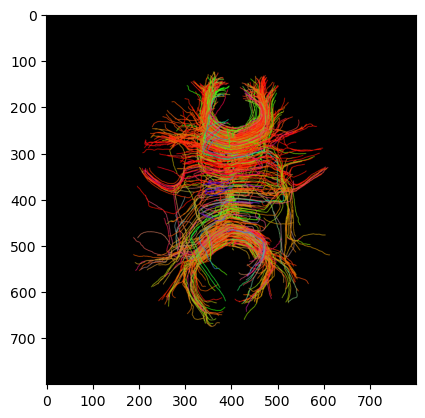

In [19]:
img = plt.imread("tractogram_probabilistic_dg_pmf_2.png")
plt.imshow(img)

In [20]:
# Interactive
window.show(scene)

In [21]:
sft.to_vox()

In [23]:
candidate_sl = sft.streamlines

In [26]:
from os.path import join as pjoin

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np

# We'll need to know where the corpus callosum is from these variables:
from dipy.core.gradients import gradient_table
import dipy.core.optimize as opt
from dipy.data import fetch_stanford_tracks, get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.streamline import load_trk
import dipy.tracking.life as life
from dipy.viz import actor, colormap as cmap, window

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")
t1_fname = get_fnames(name="stanford_t1")

data, affine, hardi_img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti_data(label_fname)
t1_data = load_nifti_data(t1_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

cc_slice = labels == 2

  0%|          | 0/71 [00:00<?, ? MB/s]

In [27]:
# Enables/disables interactive visualization
interactive = False

candidate_streamlines_actor = actor.streamtube(
    candidate_sl, colors=cmap.line_colors(candidate_sl)
)
cc_ROI_actor = actor.contour_from_roi(cc_slice, color=(1.0, 1.0, 0.0), opacity=0.5)

vol_actor = actor.slicer(t1_data)

vol_actor.display(x=40)
vol_actor2 = vol_actor.copy()
vol_actor2.display(z=35)

# Add display objects to canvas
scene = window.Scene()
scene.add(candidate_streamlines_actor)
scene.add(cc_ROI_actor)
scene.add(vol_actor)
scene.add(vol_actor2)
window.record(scene=scene, n_frames=1, out_path="life_candidates.png", size=(800, 800))


In [28]:
window.show(scene)

In [30]:
fiber_model = life.FiberModel(gtab)
inv_affine = np.linalg.inv(hardi_img.affine)

fiber_fit = fiber_model.fit(data, candidate_sl, affine=np.eye(4))

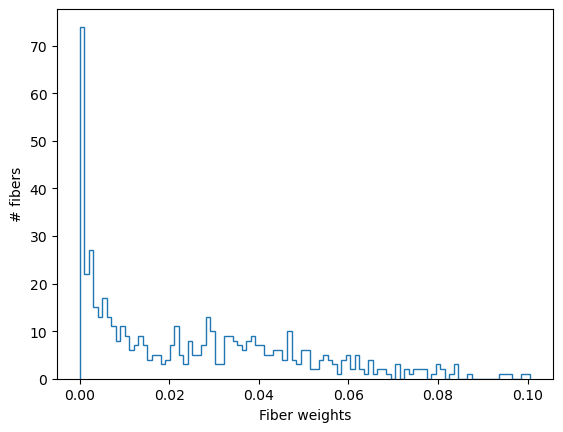

In [31]:
fig, ax = plt.subplots(1)
ax.hist(fiber_fit.beta, bins=100, histtype="step")
ax.set_xlabel("Fiber weights")
ax.set_ylabel("# fibers")
fig.savefig("beta_histogram.png")

In [32]:
optimized_sl = [np.vstack(candidate_sl)[np.where(fiber_fit.beta > 0)[0]]]
scene = window.Scene()
scene.add(actor.streamtube(optimized_sl, colors=cmap.line_colors(optimized_sl)))
scene.add(cc_ROI_actor)
scene.add(vol_actor)
window.record(scene=scene, n_frames=1, out_path="life_optimized.png", size=(800, 800))


In [33]:
window.show(scene)

In [35]:
model_predict = fiber_fit.predict()
model_error = model_predict - fiber_fit.data
model_rmse = np.sqrt(np.mean(model_error[:, 10:] ** 2, -1))

In [36]:
beta_baseline = np.zeros(fiber_fit.beta.shape[0])
pred_weighted = np.reshape(
    opt.spdot(fiber_fit.life_matrix, beta_baseline),
    (fiber_fit.vox_coords.shape[0], np.sum(~gtab.b0s_mask)),
)
mean_pred = np.empty((fiber_fit.vox_coords.shape[0], gtab.bvals.shape[0]))
S0 = fiber_fit.b0_signal

In [37]:
mean_pred[..., gtab.b0s_mask] = S0[:, None]
mean_pred[..., ~gtab.b0s_mask] = (pred_weighted + fiber_fit.mean_signal[:, None]) * S0[
    :, None
]
mean_error = mean_pred - fiber_fit.data
mean_rmse = np.sqrt(np.mean(mean_error**2, -1))

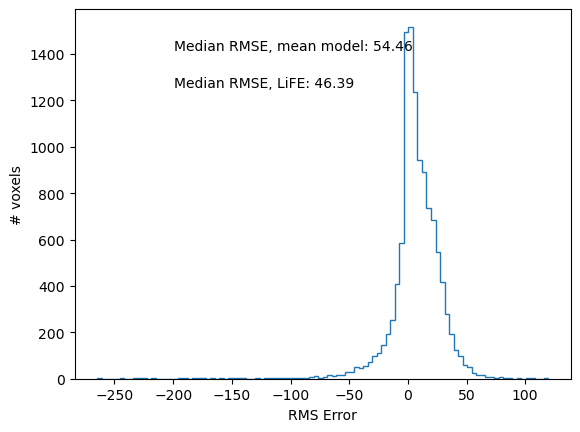

In [38]:
fig, ax = plt.subplots(1)
ax.hist(mean_rmse - model_rmse, bins=100, histtype="step")
ax.text(
    0.2,
    0.9,
    f"Median RMSE, mean model: {np.median(mean_rmse):.2f}",
    horizontalalignment="left",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.text(
    0.2,
    0.8,
    f"Median RMSE, LiFE: {np.median(model_rmse):.2f}",
    horizontalalignment="left",
    verticalalignment="center",
    transform=ax.transAxes,
)
ax.set_xlabel("RMS Error")
ax.set_ylabel("# voxels")
fig.savefig("error_histograms.png")

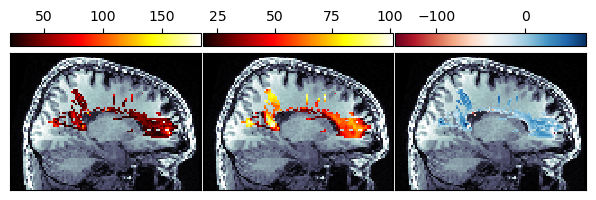

In [39]:
vol_model = np.ones(data.shape[:3]) * np.nan
vol_model[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = model_rmse
vol_mean = np.ones(data.shape[:3]) * np.nan
vol_mean[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = mean_rmse
vol_improve = np.ones(data.shape[:3]) * np.nan
vol_improve[
    fiber_fit.vox_coords[:, 0], fiber_fit.vox_coords[:, 1], fiber_fit.vox_coords[:, 2]
] = mean_rmse - model_rmse
sl_idx = 49
fig = plt.figure()
fig.subplots_adjust(left=0.05, right=0.95)
ax = AxesGrid(
    fig,
    111,
    nrows_ncols=(1, 3),
    label_mode="1",
    share_all=True,
    cbar_location="top",
    cbar_mode="each",
    cbar_size="10%",
    cbar_pad="5%",
)
ax[0].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[0].matshow(np.rot90(vol_model[sl_idx, :, :]), cmap=matplotlib.cm.hot)
ax.cbar_axes[0].colorbar(im)
ax[1].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[1].matshow(np.rot90(vol_mean[sl_idx, :, :]), cmap=matplotlib.cm.hot)
ax.cbar_axes[1].colorbar(im)
ax[2].matshow(np.rot90(t1_data[sl_idx, :, :]), cmap=matplotlib.cm.bone)
im = ax[2].matshow(np.rot90(vol_improve[sl_idx, :, :]), cmap=matplotlib.cm.RdBu)
ax.cbar_axes[2].colorbar(im)
for lax in ax:
    lax.set_xticks([])
    lax.set_yticks([])
fig.savefig("spatial_errors.png")